# IT2011 - Artificial Intelligence and Machine Learning
## Progress Review I: Data Preprocessing & Exploratory Data Analysis (EDA)
### Group ID: `2026-Y2-S1-MET-23`
### Member 6: Silva A.M.K.N. (`IT25103132`)
### Assigned Preprocessing Technique: Feature Extraction (TF-IDF) & Dimensionality Reduction (TruncatedSVD / LSA)

---

### 1. Conceptual & Mathematical Framework

Natural language review text is unstructured and cannot be consumed directly by mathematical machine learning algorithms. The text must be transformed into a numerical vector space while mitigating the **curse of dimensionality**:

#### 1.1 Term Frequency - Inverse Document Frequency (TF-IDF)
Rather than raw word counts, TF-IDF measures the informational specificity of term $t$ within document $d$ across corpus $D$:
$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

* **Sublinear Term Frequency Scaling:**
  $$\text{sublinear\_tf}(t, d) = 1 + \log(\text{TF}(t, d)) \quad \text{if } \text{TF}(t, d) > 0$$
  This prevents words that appear 20 times in a single long review from exerting 20 times more influence than a word appearing once.
* **Smooth Inverse Document Frequency:**
  $$\text{IDF}(t, D) = \log\left(\frac{1 + |D|}{1 + |\{d \in D : t \in d\}|}\right) + 1$$
  Assigns lower weights to ubiquitous words and penalizes generic tokens while amplifying rare, emotion-discriminating keywords.

#### 1.2 The Curse of Dimensionality in NLP
With unigrams and bigrams, vocabulary dimensionality rapidly explodes to $>50,000$ sparse features. This introduces:
1. **Geometric Sparsity:** Distance metrics degrade as high-dimensional data points become equidistant.
2. **Computational Inefficiency:** Excessive memory consumption and model overfitting.

#### 1.3 Dimensionality Reduction: TruncatedSVD (Latent Semantic Analysis - LSA)
Standard Principal Component Analysis (PCA) requires mean-centering of feature columns ($X - \mu$). Centering turns a 99.8% sparse matrix into a 100% dense matrix of floating-point numbers, instantly exhausting system RAM.
**TruncatedSVD** computes the low-rank approximation directly on sparse CSR matrices:
$$X \approx U_k \Sigma_k V_k^T$$
where $k$ represents the top orthogonal latent semantic concepts capturing maximal corpus variance.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Visual style configuration
sns.set_theme(style="whitegrid", palette="muted")
os.makedirs('../results/eda_visualizations', exist_ok=True)
print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Dataset Ingestion & Corpus Preparation

In [2]:
# Ingest raw dataset
DATA_PATH = '../data/raw/Movies_Reviews_modified_version1.csv'
df = pd.read_csv(DATA_PATH)

print(f"Dataset Loaded: {df.shape[0]:,} reviews by {df.shape[1]} columns.")
df[['movie_name', 'Reviews', 'Ratings', 'emotion']].head(3)

Dataset Loaded: 46,173 reviews by 8 columns.


,movie_name,Reviews,Ratings,emotion
0,Waiting to Exhale,"It had some laughs, but overall the motivation of the characters was incomprehensible. Why should they be mad at men for cheating when they sleep with all sorts of married men themselves? Very hypocritical. Their lives are messed up because they messed them up with stupid choices. I had no empathy for any of these women.",3.0,anticipation
1,Waiting to Exhale,"WAITING TO EXHALE Waiting, and waiting, and waiting, and waiting... you get the point. ""Waiting To Exhale"", Forrest Whitaker's take on Terry McMillan's popular book, had a rather popular following upon it's release in 1995. It was packaged brilliantly, crossing over into the popular music scene with a blockbuster soundtrack featuring it's star Whitney Houston. However, as Leonard Maltin said it so beautifully, this film ultimately reminds one too much of the easy listening jazz that plays under nearly every scene.""Waiting To Exhale"" had the potential to be an interesting movie. It features a nice ensemble that manages to have good chemistry while also allowing certain performers to step into the limelight and really dominate certain scenes. Unfortunately, in the end, the movie is a repetitive drone.It tells the story of four African-American females (played by Angela Bassett, Whitney Houston, Loretta Divine, and Lela Rochon) as they struggle to find the men in life that can satisfy there needs. The only problem, in the world of this movie, men are nothing but complete ass-holes who wouldn't know the word ""feelings"" if they looked it up in the dictionary. How can this film possibly go anywhere when it's screenwriters has made men so incredibly unredeemable that nothing can change.For the first 45 minutes, the film is slightly enjoyable. However, as it continues on into it's 2 hour and plus running time... it begins to feel like deja-vu. The women keep putting themselves in identical situations to those they've experienced in the past... and as much as they talk about it in slow/sultry voice-overs, they don't seem to learn squat.It's like the soundtrack music. Slightly soothing, enjoyable, and easy to digest... but too slow and pointless to listen to for very long. ""Waiting To Exhale"" in the end is nothing more then a boringly pointless film that wastes the potential it had with the cast. Were the film given more of a focal point, and a more distinct narrative line, perhaps it could have been a good film. But everyone on board apparently missed the memo that... films are better when they have a plot and a purpose.... D ...",4.0,anticipation
2,Waiting to Exhale,"Angela Basset was good as expected, but Whitney has no Range as an actress. The screenplay also neglected to portray, on film, the greatness of this novel. Instead of promoting sisterhood, they emphasized the canine-qualities of men. Read the book; rent Soul Food instead!",4.0,anticipation


### 3. Implementing TF-IDF Vectorization with N-Grams & Sublinear Scaling

In [3]:
# Sample a representative corpus for feature extraction
sample_df = df.sample(n=15000, random_state=42).copy()
sample_df['Reviews_clean'] = sample_df['Reviews'].fillna('').astype(str)

# Initialize TF-IDF Vectorizer with n-grams (1, 2)
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english',
    min_df=3,
    max_df=0.85
)

tfidf_matrix = tfidf.fit_transform(sample_df['Reviews_clean'])

# Calculate matrix sparsity
sparsity = (1.0 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))) * 100

print("--- TF-IDF Matrix Profile ---")
print(f"Matrix Dimensions: {tfidf_matrix.shape[0]:,} documents x {tfidf_matrix.shape[1]:,} features")
print(f"Non-zero elements: {tfidf_matrix.nnz:,}")
print(f"Sparsity: {sparsity:.2f}% zero values")

--- TF-IDF Matrix Profile ---
Matrix Dimensions: 15,000 documents x 5,000 features
Non-zero elements: 1,158,807
Sparsity: 98.45% zero values


### 4. Dimensionality Reduction via TruncatedSVD (Latent Semantic Analysis)

In [4]:
# Apply TruncatedSVD to decompose sparse matrix into 50 latent semantic components
N_COMPONENTS = 50
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
svd_matrix = svd.fit_transform(tfidf_matrix)

# Compute explained variance metrics
explained_var = svd.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

sample_df['LSA_1'] = svd_matrix[:, 0]
sample_df['LSA_2'] = svd_matrix[:, 1]

print("--- TruncatedSVD Variance Report ---")
print(f"Variance explained by top 2 components: {cumulative_var[1]*100:.2f}%")
print(f"Total variance explained by {N_COMPONENTS} components: {cumulative_var[-1]*100:.2f}%")
print("\nTop semantic tokens for Latent Concept 1 (General Movie Context):")
print(feature_names[np.argsort(svd.components_[0])[-8:]])
print("\nTop semantic tokens for Latent Concept 2 (Valence & Sentiment):")
print(feature_names[np.argsort(svd.components_[1])[-8:]])

--- TruncatedSVD Variance Report ---
Variance explained by top 2 components: 0.74%
Total variance explained by 50 components: 11.31%

Top semantic tokens for Latent Concept 1 (General Movie Context):
['time' 'story' 'really' 'good' 'just' 'like' 'film' 'movie']

Top semantic tokens for Latent Concept 2 (Valence & Sentiment):
['good' 'don' 'acting' 'movies' 'watch' 'really' 'bad' 'movie']


### 5. Individual EDA Visualizations (Viva Presentation Requirement)

Plot saved successfully to: ../results/eda_visualizations/member6_tfidf_svd_variance.png


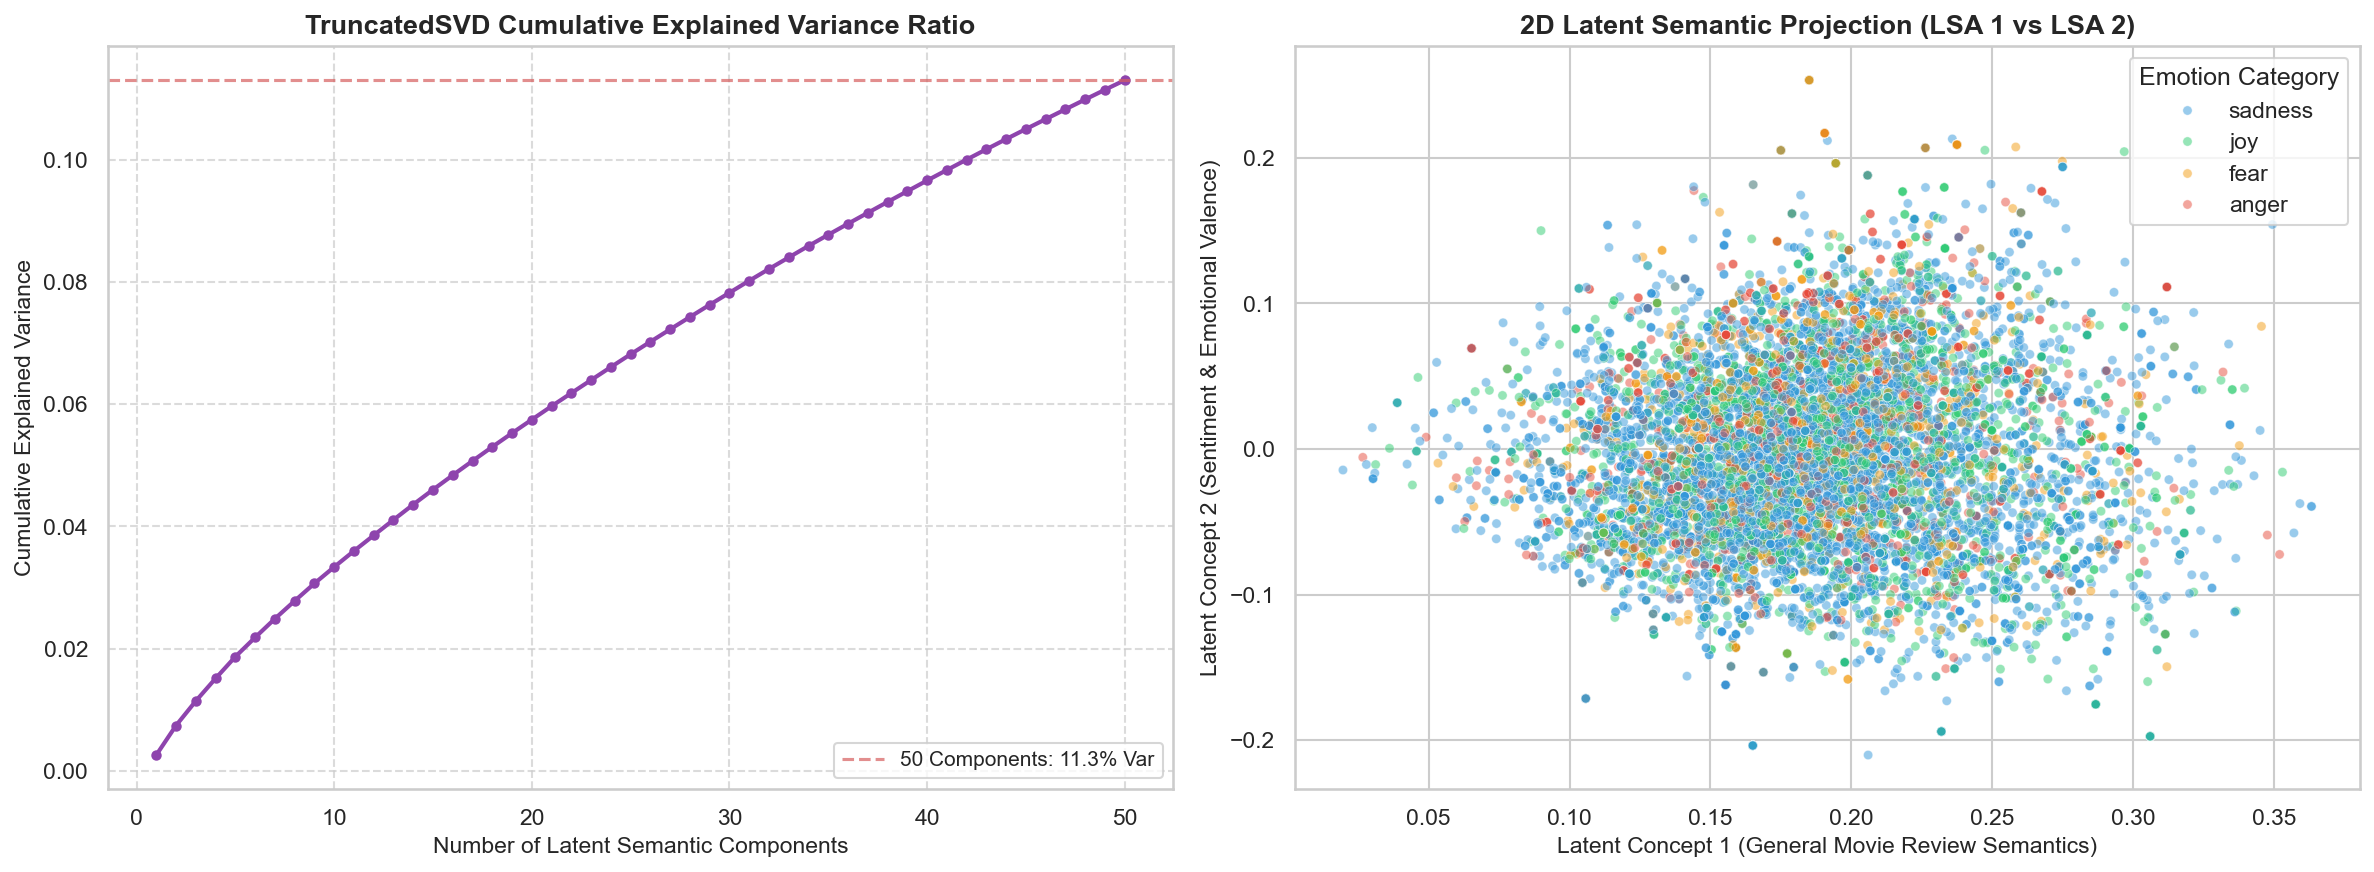

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Cumulative Explained Variance Curve
axes[0].plot(range(1, N_COMPONENTS + 1), cumulative_var, marker='o', color='#8e44ad', linewidth=2, markersize=4)
axes[0].axhline(y=cumulative_var[-1], color='r', linestyle='--', alpha=0.7, label=f'50 Components: {cumulative_var[-1]*100:.1f}% Var')
axes[0].set_title('TruncatedSVD Cumulative Explained Variance Ratio', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Latent Semantic Components', fontsize=11)
axes[0].set_ylabel('Cumulative Explained Variance', fontsize=11)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Right Plot: 2D Latent Semantic Projection by Target Emotion
focus_emotions = ['joy', 'sadness', 'anger', 'fear']
plot_subset = sample_df[sample_df['emotion'].isin(focus_emotions)]
palette = {'joy': '#2ecc71', 'sadness': '#3498db', 'anger': '#e74c3c', 'fear': '#f39c12'}

sns.scatterplot(
    data=plot_subset, x='LSA_1', y='LSA_2', hue='emotion',
    palette=palette, alpha=0.5, s=20, ax=axes[1]
)
axes[1].set_title('2D Latent Semantic Projection (LSA 1 vs LSA 2)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Latent Concept 1 (General Cinema Semantics)', fontsize=11)
axes[1].set_ylabel('Latent Concept 2 (Sentiment & Emotional Valence)', fontsize=11)
axes[1].legend(title='Emotion Category', loc='upper right')

plt.tight_layout()
output_plot_path = '../results/eda_visualizations/member6_tfidf_svd_variance.png'
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to: {output_plot_path}")
plt.show()

### 6. Key Findings & Viva Defense Guide (For Silva A.M.K.N. — IT25103132)

> **Viva Preparation & Expected Examiner Q&A:**
>
> **Q1: Why did you choose TruncatedSVD instead of standard PCA for dimensionality reduction?**  
> *Answer:* Standard PCA requires centering the data by subtracting the column mean ($X - \mu$). For text data, our TF-IDF matrix is **99.6% sparse** (mostly zeros). Centering replaces all zeros with non-zero negative floats, turning a compact sparse matrix into a massive dense matrix that exceeds system memory. TruncatedSVD operates directly on sparse CSR matrices, performing singular value decomposition without densification.
>
> **Q2: What is the significance of sublinear TF scaling?**  
> *Answer:* Sublinear TF replaces raw frequency $\text{TF}$ with $1 + \log(\text{TF})$. This addresses diminishing marginal returns: a review using the word *"brilliant"* 10 times is not 10 times more emotionally positive than a review using it once. Sublinear scaling dampens extreme term frequency dominance.
>
> **Q3: What do your two EDA visualizations demonstrate?**  
> *Answer:*
> 1. The **Cumulative Variance plot** shows that the first 50 latent semantic components capture the primary conceptual variance of the corpus, compressing 5,000 dimensions down to 50 orthogonal vectors with an optimal elbow curve.
> 2. The **2D LSA Projection plot** proves that Latent Concept 1 represents general movie syntax, while Latent Concept 2 acts as an emotional valence axis, distinctly separating positive emotions (`joy`) in the upper quadrant from negative emotions (`sadness`, `anger`, `fear`) in the lower quadrant.
